In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score,f1_score,confusion_matrix,precision_score,recall_score,precision_recall_curve
data= pd.read_csv("dataset.csv")
data.mental_health_risk.value_counts()




mental_health_risk
1    11823
0     9357
2     3820
Name: count, dtype: int64

In [3]:
#binary classification
#extract the data
bdata=[]
for i in range(len(data)):
    if data.mental_health_risk[i]!=2:
        bdata.append(data.loc[i])
bdata=pd.DataFrame(bdata)  
bdata.index=range(len(bdata))  
print(bdata.mental_health_risk.value_counts())
bdata.head()  

mental_health_risk
1    11823
0     9357
Name: count, dtype: int64


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0
3,58,Male,Married,Master,Employed,9.4,12.8,5.9,7,7,...,6,3,1,3,0,0,1,0,0,0
4,22,Other,Married,PhD,Employed,6.9,11.6,6.4,10,10,...,4,5,7,7,0,0,0,0,1,0


In [4]:
#split the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(bdata.drop("mental_health_risk",axis=1),bdata.mental_health_risk,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# align columns (important)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


(16944, 24) (4236, 24) (16944,) (4236,)


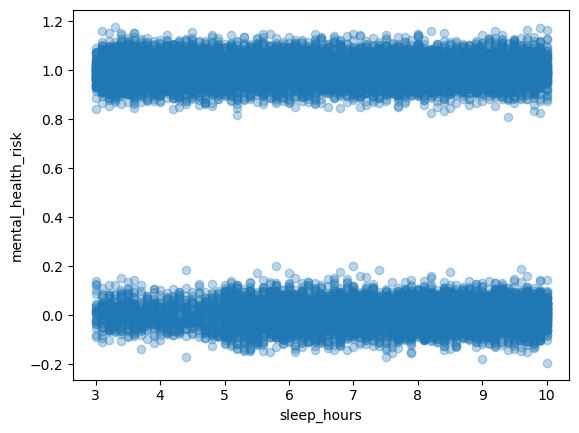

In [5]:
import numpy as np

y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['sleep_hours'], y_jitter, alpha=0.3)
plt.xlabel('sleep_hours')
plt.ylabel('mental_health_risk')
plt.show()

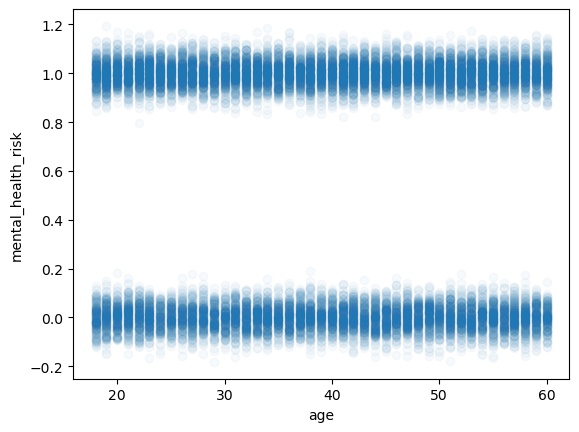

In [21]:

y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['age'], y_jitter, alpha=0.03)
plt.xlabel('age')
plt.ylabel('mental_health_risk')
plt.show()

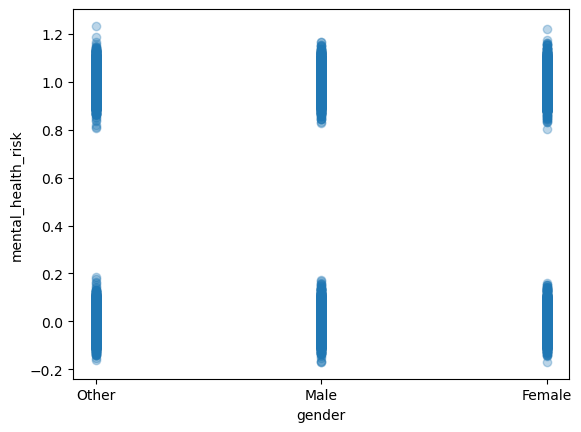

In [8]:
y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['gender'], y_jitter, alpha=0.3)
plt.xlabel('gender')
plt.ylabel('mental_health_risk')
plt.show()

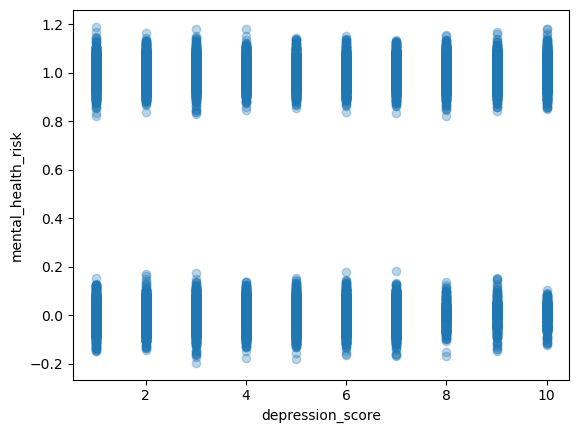

In [9]:

y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['depression_score'], y_jitter, alpha=0.3)
plt.xlabel('depression_score')
plt.ylabel('mental_health_risk')
plt.show()

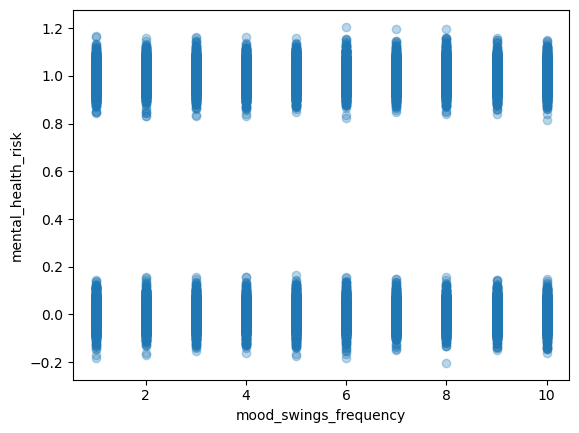

In [10]:
y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['mood_swings_frequency'], y_jitter, alpha=0.3)
plt.xlabel('mood_swings_frequency')
plt.ylabel('mental_health_risk')
plt.show()

In [7]:
model= LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))

accuracy 0.7974504249291785
f1 score 0.8228004956629492
confusion matrix [[1386  481]
 [ 377 1992]]
precision 0.8054993934492519
recall 0.8408611228366399


In [8]:
from sklearn.tree import DecisionTreeClassifier
tree= DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(x_train, y_train)
y_pred_tree= tree.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_tree))
print("f1 score",f1_score(y_test,y_pred_tree))
print("confusion matrix",confusion_matrix(y_test,y_pred_tree))
print("precision",precision_score(y_test,y_pred_tree))
print("recall",recall_score(y_test,y_pred_tree))


accuracy 0.9990557129367328
f1 score 0.9991554054054054
confusion matrix [[1866    1]
 [   3 2366]]
precision 0.9995775242923531
recall 0.9987336428872943


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_rf))
print("f1 score",f1_score(y_test,y_pred_rf))
print("confusion matrix",confusion_matrix(y_test,y_pred_rf))
print("precision",precision_score(y_test,y_pred_rf))
print("recall",recall_score(y_test,y_pred_rf))

accuracy 0.990084985835694
f1 score 0.9911054637865311
confusion matrix [[1854   13]
 [  29 2340]]
precision 0.994475138121547
recall 0.9877585479105108


In [17]:

from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=50,
    max_depth=10,
    learning_rate=0.1,
    eval_metric='logloss'
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("accuracy", accuracy_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("confusion matrix", confusion_matrix(y_test, y_pred))
print("precision", precision_score(y_test, y_pred))
print("recall", recall_score(y_test, y_pred))


accuracy 0.9992917847025495
f1 score 0.9993664202745512
confusion matrix [[1867    0]
 [   3 2366]]
precision 1.0
recall 0.9987336428872943


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [21]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.5).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.7355 - loss: 0.5292 - val_accuracy: 0.8032 - val_loss: 0.4166
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.8157 - loss: 0.3928 - val_accuracy: 0.8185 - val_loss: 0.3801
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - accuracy: 0.8355 - loss: 0.3521 - val_accuracy: 0.8359 - val_loss: 0.3446
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.8557 - loss: 0.3172 - val_accuracy: 0.8457 - val_loss: 0.3263
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.8656 - loss: 0.2952 - val_accuracy: 0.8513 - val_loss: 0.3181
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.8721 - loss: 0.2804 - val_accuracy: 0.8551 - val_loss: 0.3131
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - accuracy: 0.8794 - loss: 0.2684 - val_accuracy: 0.8607 - val_loss: 0.3097
Epoch 8/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.8850 - loss: 0.2586 - val_accurac

In [25]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))


Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7700 - loss: 0.4612 - recall: 0.8412 - val_accuracy: 0.8238 - val_loss: 0.3629 - val_recall: 0.9493
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8433 - loss: 0.3300 - recall: 0.8880 - val_accuracy: 0.8433 - val_loss: 0.3382 - val_recall: 0.9354
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8666 - loss: 0.2788 - recall: 0.8921 - val_accuracy: 0.8528 - val_loss: 0.3270 - val_recall: 0.9391
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8916 - loss: 0.2322 - recall: 0.9123 - val_accuracy: 0.8554 - val_loss: 0.3512 - val_recall: 0.9503
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9177 - loss: 0.1915 - recall: 0.9355 - val_accuracy: 0.8829 - val_loss: 0.3044 - val_recall: 0.9311
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9379 - loss: 0.1452 - recall: 0.9516 - val_accuracy: 0.8846 - val_loss: 0.3385 - val_recall: 0.9322
Epoch 7/20
4

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7673 - loss: 0.4618 - recall: 0.8358 - val_accuracy: 0.8280 - val_loss: 0.3653 - val_recall: 0.9439
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8449 - loss: 0.3321 - recall: 0.8876 - val_accuracy: 0.8410 - val_loss: 0.3467 - val_recall: 0.9391
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8617 - loss: 0.2820 - recall: 0.8924 - val_accuracy: 0.8460 - val_loss: 0.3454 - val_recall: 0.9269
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8849 - loss: 0.2435 - recall: 0.9025 - val_accuracy: 0.8625 - val_loss: 0.3258 - val_recall: 0.9295
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9081 - loss: 0.1990 - recall: 0.9266 - val_accuracy: 0.8560 - val_loss: 0.3815 - val_recall: 0.9375
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9299 - loss: 0.1606 - recall: 0.9452 - val_accuracy: 0.8646 - val_loss: 0.4072 - val_recall: 0.9519
Epoch 7/20
424/

In [62]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7697 - loss: 0.4558 - recall: 0.8370 - val_accuracy: 0.8292 - val_loss: 0.3628 - val_recall: 0.9445
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8464 - loss: 0.3263 - recall: 0.8871 - val_accuracy: 0.8460 - val_loss: 0.3356 - val_recall: 0.9285
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8726 - loss: 0.2697 - recall: 0.8966 - val_accuracy: 0.8663 - val_loss: 0.3219 - val_recall: 0.9354
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9033 - loss: 0.2174 - recall: 0.9147 - val_accuracy: 0.8772 - val_loss: 0.3049 - val_recall: 0.9370
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9283 - loss: 0.1692 - recall: 0.9367 - val_accuracy: 0.8811 - val_loss: 0.3298 - val_recall: 0.9418
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9477 - loss: 0.1301 - recall: 0.9534 - val_accuracy: 0.8849 - val_loss: 0.3221 - val_recall: 0.9482
Epoch 7/20
424/

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7710 - loss: 0.4572 - recall: 0.8296 - val_accuracy: 0.8280 - val_loss: 0.3620 - val_recall: 0.9407
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8450 - loss: 0.3293 - recall: 0.8851 - val_accuracy: 0.8457 - val_loss: 0.3345 - val_recall: 0.9407
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8717 - loss: 0.2765 - recall: 0.8956 - val_accuracy: 0.8681 - val_loss: 0.3070 - val_recall: 0.9429
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9030 - loss: 0.2212 - recall: 0.9176 - val_accuracy: 0.8852 - val_loss: 0.2851 - val_recall: 0.9461
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9246 - loss: 0.1707 - recall: 0.9350 - val_accuracy: 0.8861 - val_loss: 0.3198 - val_recall: 0.9482
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9457 - loss: 0.1316 - recall: 0.9548 - val_accuracy: 0.8899 - val_loss: 0.3261 - val_recall: 0.9487
Epoch 7/20
424/

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.7).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7677 - loss: 0.4578 - recall: 0.8324 - val_accuracy: 0.8292 - val_loss: 0.3619 - val_recall: 0.9429
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8468 - loss: 0.3298 - recall: 0.8855 - val_accuracy: 0.8427 - val_loss: 0.3395 - val_recall: 0.9386
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8696 - loss: 0.2779 - recall: 0.8965 - val_accuracy: 0.8563 - val_loss: 0.3185 - val_recall: 0.9381
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8941 - loss: 0.2287 - recall: 0.9106 - val_accuracy: 0.8690 - val_loss: 0.3154 - val_recall: 0.9258
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9194 - loss: 0.1810 - recall: 0.9320 - val_accuracy: 0.8711 - val_loss: 0.3453 - val_recall: 0.9386
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9397 - loss: 0.1392 - recall: 0.9503 - val_accuracy: 0.8722 - val_loss: 0.3707 - val_recall: 0.9493
Epoch 7/20
424/

In [64]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.5).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7679 - loss: 0.4591 - recall: 0.8429 - val_accuracy: 0.8283 - val_loss: 0.3590 - val_recall: 0.9418
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8470 - loss: 0.3261 - recall: 0.8837 - val_accuracy: 0.8463 - val_loss: 0.3319 - val_recall: 0.9397
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8762 - loss: 0.2642 - recall: 0.8947 - val_accuracy: 0.8719 - val_loss: 0.2984 - val_recall: 0.9263
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9083 - loss: 0.2093 - recall: 0.9173 - val_accuracy: 0.8814 - val_loss: 0.2916 - val_recall: 0.9434
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1600 - recall: 0.9440 - val_accuracy: 0.8834 - val_loss: 0.3116 - val_recall: 0.9365
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9463 - loss: 0.1321 - recall: 0.9527 - val_accuracy: 0.8867 - val_loss: 0.3429 - val_recall: 0.9541
Epoch 7/20
424/

In [25]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.25).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7738 - loss: 0.4565 - recall: 0.8483 - val_accuracy: 0.8280 - val_loss: 0.3616 - val_recall: 0.9349
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3291 - recall: 0.8859 - val_accuracy: 0.8463 - val_loss: 0.3350 - val_recall: 0.9407
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8740 - loss: 0.2765 - recall: 0.8987 - val_accuracy: 0.8625 - val_loss: 0.3155 - val_recall: 0.9423
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9021 - loss: 0.2205 - recall: 0.9170 - val_accuracy: 0.8758 - val_loss: 0.2965 - val_recall: 0.9455
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9262 - loss: 0.1699 - recall: 0.9410 - val_accuracy: 0.8891 - val_loss: 0.3152 - val_recall: 0.9546
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9462 - loss: 0.1333 - recall: 0.9543 - val_accuracy: 0.8917 - val_loss: 0.3572 - val_recall: 0.9568
Epoch 7/20
424/

In [70]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.45).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7721 - loss: 0.4586 - recall: 0.8404 - val_accuracy: 0.8265 - val_loss: 0.3682 - val_recall: 0.9418
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8439 - loss: 0.3348 - recall: 0.8844 - val_accuracy: 0.8395 - val_loss: 0.3385 - val_recall: 0.9359
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.2831 - recall: 0.8974 - val_accuracy: 0.8557 - val_loss: 0.3273 - val_recall: 0.9397
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8942 - loss: 0.2336 - recall: 0.9103 - val_accuracy: 0.8734 - val_loss: 0.3125 - val_recall: 0.9466
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9181 - loss: 0.1856 - recall: 0.9319 - val_accuracy: 0.8864 - val_loss: 0.2996 - val_recall: 0.9386
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9386 - loss: 0.1402 - recall: 0.9468 - val_accuracy: 0.8920 - val_loss: 0.3083 - val_recall: 0.9413
Epoch 7/20
424/

In [28]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.25).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7788 - loss: 0.4526 - recall: 0.8592 - val_accuracy: 0.8345 - val_loss: 0.3559 - val_recall: 0.9354
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8478 - loss: 0.3257 - recall: 0.8832 - val_accuracy: 0.8501 - val_loss: 0.3361 - val_recall: 0.9370
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8717 - loss: 0.2769 - recall: 0.8985 - val_accuracy: 0.8622 - val_loss: 0.3173 - val_recall: 0.9333
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8958 - loss: 0.2307 - recall: 0.9118 - val_accuracy: 0.8778 - val_loss: 0.2979 - val_recall: 0.9429
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9210 - loss: 0.1785 - recall: 0.9326 - val_accuracy: 0.8805 - val_loss: 0.3058 - val_recall: 0.9418
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9439 - loss: 0.1358 - recall: 0.9518 - val_accuracy: 0.8926 - val_loss: 0.3097 - val_recall: 0.9359
Epoch 7/20
424/

In [80]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=18, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.35).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/18


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7697 - loss: 0.4570 - recall: 0.8484 - val_accuracy: 0.8309 - val_loss: 0.3605 - val_recall: 0.9402
Epoch 2/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8459 - loss: 0.3270 - recall: 0.8840 - val_accuracy: 0.8513 - val_loss: 0.3302 - val_recall: 0.9338
Epoch 3/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.2663 - recall: 0.8989 - val_accuracy: 0.8660 - val_loss: 0.3105 - val_recall: 0.9359
Epoch 4/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9029 - loss: 0.2141 - recall: 0.9144 - val_accuracy: 0.8790 - val_loss: 0.3044 - val_recall: 0.9429
Epoch 5/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9307 - loss: 0.1636 - recall: 0.9421 - val_accuracy: 0.8885 - val_loss: 0.3088 - val_recall: 0.9450
Epoch 6/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9442 - loss: 0.1341 - recall: 0.9524 - val_accuracy: 0.8932 - val_loss: 0.3079 - val_recall: 0.9333
Epoch 7/18
424/

Epoch 1/18


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7738 - loss: 0.4551 - recall: 0.8410 - val_accuracy: 0.8324 - val_loss: 0.3601 - val_recall: 0.9386
Epoch 2/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8461 - loss: 0.3299 - recall: 0.8853 - val_accuracy: 0.8495 - val_loss: 0.3311 - val_recall: 0.9317
Epoch 3/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8731 - loss: 0.2758 - recall: 0.8969 - val_accuracy: 0.8610 - val_loss: 0.3090 - val_recall: 0.9253
Epoch 4/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.2217 - recall: 0.9145 - val_accuracy: 0.8843 - val_loss: 0.2842 - val_recall: 0.9413
Epoch 5/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9263 - loss: 0.1697 - recall: 0.9362 - val_accuracy: 0.8923 - val_loss: 0.3047 - val_recall: 0.9386
Epoch 6/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9483 - loss: 0.1281 - recall: 0.9554 - val_accuracy: 0.8832 - val_loss: 0.3504 - val_recall: 0.9589
Epoch 7/18
424/

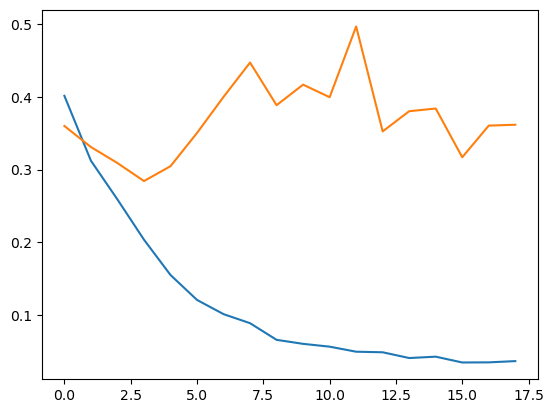

In [37]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=model.fit(x_train_scaled, y_train, epochs=18, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.35).astype("int32")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Epoch 1/18


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7679 - loss: 0.4610 - recall: 0.8427 - val_accuracy: 0.8250 - val_loss: 0.3665 - val_recall: 0.9407
Epoch 2/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8442 - loss: 0.3289 - recall: 0.8853 - val_accuracy: 0.8451 - val_loss: 0.3396 - val_recall: 0.9391
Epoch 3/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8732 - loss: 0.2729 - recall: 0.8964 - val_accuracy: 0.8675 - val_loss: 0.3142 - val_recall: 0.9418
Epoch 4/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9064 - loss: 0.2168 - recall: 0.9194 - val_accuracy: 0.8764 - val_loss: 0.3154 - val_recall: 0.9552
Epoch 5/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9325 - loss: 0.1670 - recall: 0.9444 - val_accuracy: 0.8905 - val_loss: 0.2996 - val_recall: 0.9349
Epoch 6/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9482 - loss: 0.1307 - recall: 0.9548 - val_accuracy: 0.8947 - val_loss: 0.3091 - val_recall: 0.9391
Epoch 7/18
424/

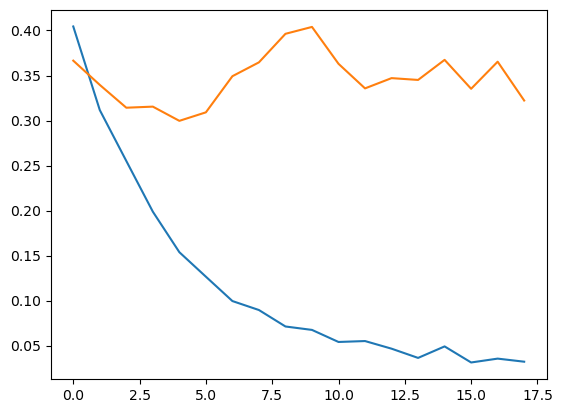

In [16]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


tf.random.set_seed(42)
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=mlp_model.fit(x_train_scaled, y_train, epochs=18, batch_size=32, validation_split=0.2)
y_pred_nn = (mlp_model.predict(x_test_scaled) > 0.35).astype("int32")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step


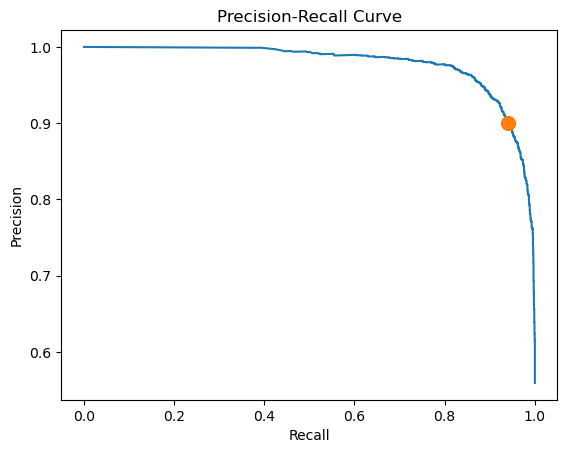

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = mlp_model.predict(x_test_scaled).ravel()

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)


plt.plot(recall, precision)
plt.plot(0.94,0.90, marker='o', markersize=10, label='Point at Recall=0.4')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Epoch 1/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.6292 - loss: 0.6398 - recall: 0.9235 - val_accuracy: 0.7456 - val_loss: 0.5308 - val_recall: 0.8489
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - accuracy: 0.7761 - loss: 0.4711 - recall: 0.8429 - val_accuracy: 0.8176 - val_loss: 0.3938 - val_recall: 0.8671
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8396 - loss: 0.3499 - recall: 0.8719 - val_accuracy: 0.8504 - val_loss: 0.3289 - val_recall: 0.8820
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.8576 - loss: 0.3028 - recall: 0.8820 - val_accuracy: 0.8569 - val_loss: 0.3058 - val_recall: 0.8825
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.8664 - loss: 0.2833 - recall: 0.8874 - val_accuracy: 0.8622 - val_loss: 0.2950 - val_recall: 0.8841
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.8740 - loss: 0.2719 - recall: 0.8941 - val_accuracy: 0.8678 - val_loss: 0.2887 - val_recall:

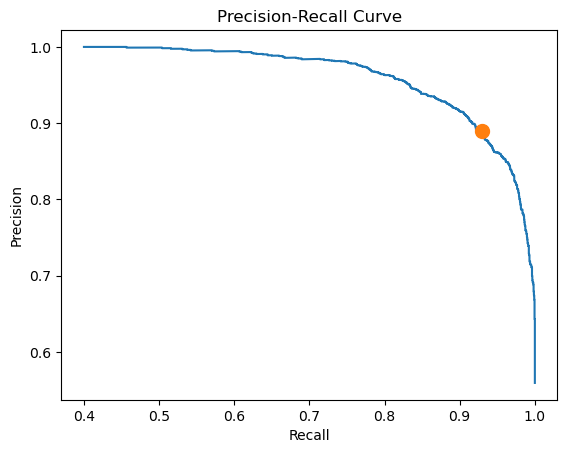

accuracy 0.8930594900849859
f1 score 0.9063081695966908
confusion matrix [[1592  275]
 [ 178 2191]]
precision 0.8884833738848338
recall 0.9248628113127902


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Softmax, Multiply
from tensorflow.keras.models import Model

inputs = Input(shape=(x_train_scaled.shape[1],))

attn = Dense(x_train_scaled.shape[1], activation='softmax')(inputs)

weighted = Multiply()([inputs, attn])

x = Dense(256, activation='relu')(weighted)
outputs = Dense(1, activation='sigmoid')(x)

model_attn = Model(inputs, outputs)

model_attn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=model_attn.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2,callbacks=[early_stop])
y_pred_nn = (model_attn.predict(x_test_scaled) > 0.5).astype("int32")

y_probs = model_attn.predict(x_test_scaled).ravel()
precision_at_recall_0_4 = []
recall_at_recall_0_4 = []
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
for i in range(len(thresholds)):
    if recall[i]>0.4:
        precision_at_recall_0_4.append(precision[i])
        recall_at_recall_0_4.append(recall[i])

plt.plot(recall_at_recall_0_4, precision_at_recall_0_4, )
plt.plot(0.93,0.89, marker='o', markersize=10, label='Point at Recall=0.4')  

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))


In [10]:
from tensorflow.keras.layers import Input, Dense, Multiply
from tensorflow.keras.models import Model

inputs = Input(shape=(x_train_scaled.shape[1],))

# attention weights over features
attn = Dense(x_train_scaled.shape[1], activation='softmax')(inputs)

# apply attention
weighted = Multiply()([inputs, attn])

# pass to classifier
x = Dense(1024, activation='relu')(weighted)
x1 = Dense(256, activation='relu')(x)
x2 = Dense(256, activation='relu')(x1)
outputs = Dense(1, activation='sigmoid')(x)

model_attn = Model(inputs, outputs)

model_attn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model_attn.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stop])

# Make predictions
y_pred_nn = (model_attn.predict(x_test_scaled) > 0.5).astype("int32")

# Print evaluation metrics
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6326 - loss: 0.6252 - val_accuracy: 0.7418 - val_loss: 0.5160
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7763 - loss: 0.4660 - val_accuracy: 0.8197 - val_loss: 0.3908
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8368 - loss: 0.3575 - val_accuracy: 0.8466 - val_loss: 0.3327
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.8591 - loss: 0.3130 - val_accuracy: 0.8563 - val_loss: 0.3105
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.8667 - loss: 0.2906 - val_accuracy: 0.8634 - val_loss: 0.2978
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8720 - loss: 0.2753 - val_accuracy: 0.8663 - val_loss: 0.2880
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8769 - loss: 0.2627 - val_accuracy: 0.8716 - val_loss: 0.2783
Epoch 8/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8853 - loss: 0.2505 - val_accura

In [17]:
y_probs_mlp=mlp_model.predict(x_test_scaled).ravel()
y_probs_attn= model_attn.predict(x_test_scaled).ravel()

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def best_recall_at_precision(y_true, y_probs, target_precision=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    mask = precision >= target_precision

    if not np.any(mask):
        return None  # no valid threshold

    best_idx = np.argmax(recall[mask])

    return {
        "precision": precision[mask][best_idx],
        "recall": recall[mask][best_idx],
        "threshold": thresholds[mask][best_idx]
    }
